# Utilization

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy
import sys
sys.path.insert(0, "../src/")
from FwdNeuron import *
from DeepEligNeuron import *
from Network import *
from inputFuc import *
from utils import *
from plotting import *

# Compare learning

## Teacher-student in Multi-layer

reach steady state with error: 0.095459


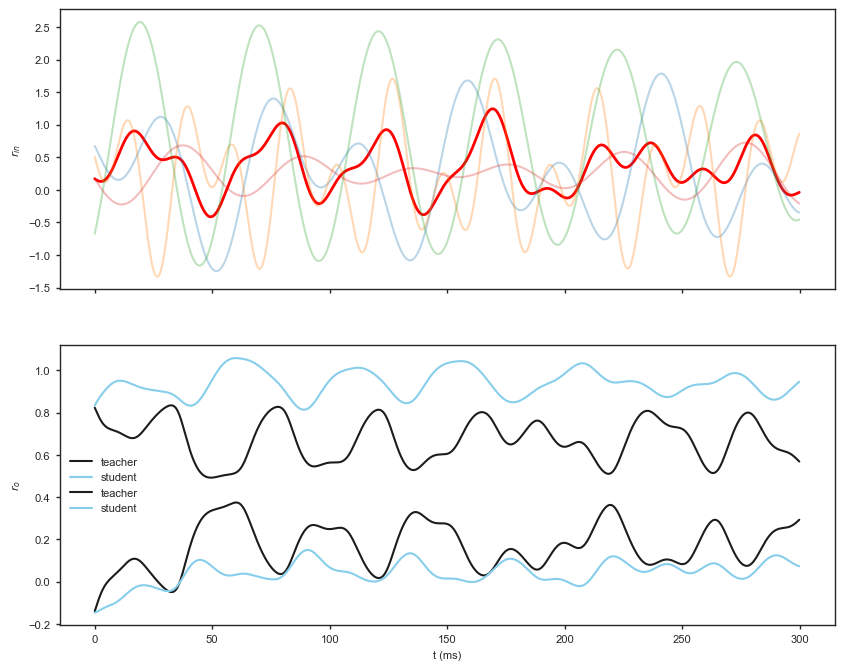

In [115]:
#### With P learning ###
dt = 0.2 #ms

init_phase = 300 #ms
init_phase_steps = int(init_phase/dt) 
learn_phase = 12000 # ms
learn_phase_steps = int(learn_phase/dt) 
eval_phase = 200 # ms
eval_phase_steps = int(eval_phase/dt)

# init both teacher and student net
n_in, n_hidden1, n_hidden2, n_out = 4, 3, 2, 2
beta=0.05
activation='sigmoid'

student = DENetwork(
    layers=[
        FwdDENeurons(n_in=n_in, n_neurons=n_hidden1, tau=[1.7, 3., 7.], lr_w=1.0,
                     activation=activation, dt=dt, scale=0.6),
        LastFwdDENeurons(n_in=n_hidden1, n_neurons=n_hidden2, tau=[8, 17], lr_w=0.2,
                     activation=activation, dt=dt, scale=1.6),
        FwdNeurons(n_in=n_hidden2, n_neurons=n_out, tau=dt, 
                   lr_w=0.0, activation='linear', dt=dt, beta=beta)
    ],)

# n_in, n_hidden1, n_out = 3, 2, 1
# student = FwdNetwork(
#     layers=[
#         FwdEPNeurons(n_in=n_in, n_neurons=n_hidden1, tau=[13, 67], lr_w=1.5,
#                      activation=activation, dt=dt, scale=1.6),
#         FwdNeurons(n_in=n_hidden1, n_neurons=n_out, tau=dt, 
#                    lr_w=0.0, activation='linear', dt=dt, beta=beta)
#     ],)


student2 = FwdNetwork(net=student, layers=FwdEPNeurons)

student3 = FwdNetwork(net=student, layers=FwdGLENeurons)
student_naive = copy.deepcopy(student2)
teacher = copy.deepcopy(student2)

Students={'DeepElig':student, 'Eprop':student2, 'GLE':student3, 'naive':student_naive}



# deviate teacher by small perturbation
for i, l in enumerate(student.layers[:-1]):
    deviate = torch.randn(l.W_in.shape)*6e-1
    teacher.layers[i].W_in += deviate
# deviate = torch.randn(teacher.layers[-1].W_in.shape)*1e-2
# teacher.layers[-1].W_in += deviate

input_fuc = mul_sin_function(n=n_in, n_sin=2, period=(20, 80), bias = (-0.5, 0.5), magnitude=(0.2, 1), phase = (0, 6), dt=dt)
#input_fuc = mul_sin_function(n=n_in, n_sin=2, period=(15, 40), bias=(-0.1, 0.1), magnitude=(0.2, 1.0), phase=(0, 6), dt=dt)
#input_fuc = low_pass_OU(size=n_in, lp_tau=(0.5, 2), tau=(10, 25), mu=(-0.2, 0.2), sigma=(0.1, 0.5), dt = dt)


#recorders
Rcd = Recorder(['input', 'teacher', 'student'])

with torch.no_grad():
    
    for t in range(init_phase_steps):
        inp = input_fuc(t)
        r_out_target, u_out_target = teacher.step(inp)
        r_out, u_out = student.step(inp)
        r_out1, u_out = student3.step(inp)
        if (r_out != r_out1).any():
            print(r_out, r_out1)
        error = u_out_target - u_out
        student.prop(error)
        student2.prop(error)
        Rcd.rec([inp, u_out_target, u_out])
        
    print("reach steady state with error: %f"%(error**2).mean().item())

Rcd.finish()

fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
x = np.arange(0, init_phase, dt)
axs[0].plot(x, Rcd['input'].mean(axis=0), color='r', linewidth=2)
for i in range(n_in):
    axs[0].plot(x, Rcd['input'][i][0:], alpha = 0.3)
for i in range(n_out):
    axs[1].plot(x, Rcd['teacher'][i][0:], label="teacher", color = black)
    axs[1].plot(x, Rcd['student'][i][0:], label="student", color = lightblue)
axs[1].legend()
axs[1].set_xlabel("t (ms)")
axs[0].set_ylabel(r"$r_{in}$")
axs[1].set_ylabel(r"$r_o$")

plt.show()

In [116]:
Cum_errors = 3*[(error**2).mean().item()]
error_record, mismatch_record = [], []
cum_eps = 0
Students['Eprop'].align(student)
Students['GLE'].align(student)
Rcd = Recorder(['dt_tau_de', 'rhod'])

with torch.no_grad():
    for t in range(learn_phase_steps):
        t += init_phase_steps
        inp = input_fuc(t)
        r_out_target, u_out_target = teacher.step(inp)
        
        for i, stu in enumerate(['DeepElig', 'Eprop', 'GLE']):
            r_out, u_out = Students[stu].step(inp)
            error = u_out_target - u_out
            Students[stu].prop(error)
            Students[stu].learnW()
            Cum_errors[i] = 0.999*Cum_errors[i] + 0.001*(error**2).mean().item()
        
        if (t*dt)%100==0:
            error_record.append(list(Cum_errors))
            
            print("target: ", u_out_target.mean().numpy(), "output: ", u_out.mean().numpy(), 
                  " error: %5e, t: %d ms"%(Cum_errors[0], t*dt))
#Rcd.finish()


target:  0.4308834 output:  0.5103282  error: 9.546077e-02, t: 300 ms
target:  0.42622373 output:  0.49427807  error: 7.434443e-02, t: 400 ms
target:  0.40875095 output:  0.48125386  error: 5.108615e-02, t: 500 ms
target:  0.4392761 output:  0.5120256  error: 3.713337e-02, t: 600 ms
target:  0.43437272 output:  0.49708065  error: 2.601379e-02, t: 700 ms
target:  0.4062082 output:  0.49229196  error: 1.922474e-02, t: 800 ms
target:  0.43707484 output:  0.5173714  error: 1.558087e-02, t: 900 ms
target:  0.43248177 output:  0.5220249  error: 1.389195e-02, t: 1000 ms
target:  0.38693747 output:  0.47222948  error: 1.113160e-02, t: 1100 ms
target:  0.43881333 output:  0.5261189  error: 1.029950e-02, t: 1200 ms
target:  0.42123574 output:  0.49262238  error: 8.859063e-03, t: 1300 ms
target:  0.4049734 output:  0.4852754  error: 7.940905e-03, t: 1400 ms
target:  0.41038257 output:  0.47210157  error: 7.268901e-03, t: 1500 ms
target:  0.434216 output:  0.48066384  error: 5.995576e-03, t: 1600 

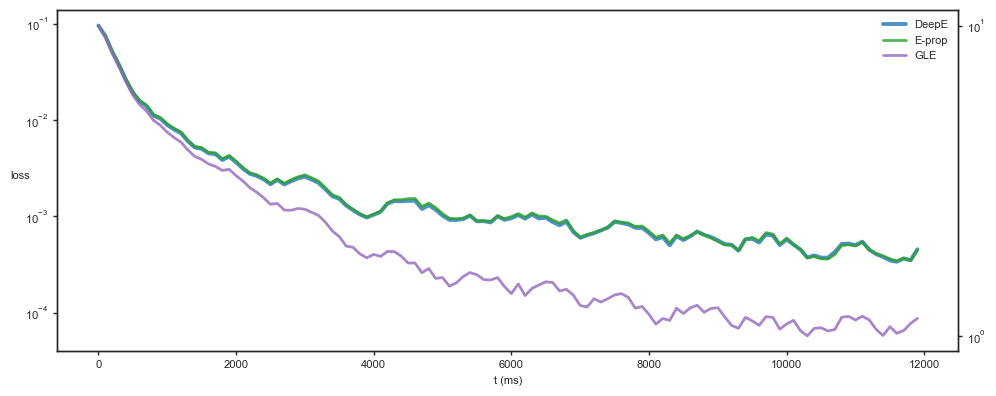

In [117]:
Error_record = np.array(error_record).T
fig = plt.figure(figsize=(10, 4))
time = np.arange(Error_record.shape[1])*100
ax = fig.add_subplot(111)
ax2 = ax.twinx()
ax.set_yscale('log')
ax.set_ylabel('loss', rotation=0)
ax2.set_yscale('log')
#ax2.set_ylabel(r"$\mathbf{u}^{ɑ}$", rotation=0)
l1,  = ax.plot(time, Error_record[0], label="DeepE", color=blue, linewidth=2.8, alpha=0.8)
l11, = ax.plot(time, Error_record[1], label="E-prop", color=green, linewidth=2., alpha=0.8)
l12, = ax.plot(time, Error_record[2], label="GLE", color=purple, linewidth=2., alpha=0.8)
lines = [l1, l11, l12]
labels = [line.get_label() for line in lines]
ax.legend(lines, labels, loc='upper right', frameon=False)
ax.set_xlabel('t (ms)')

plt.tight_layout()
#plt.savefig('./fig/losscurvecompare2L.png')
plt.show()

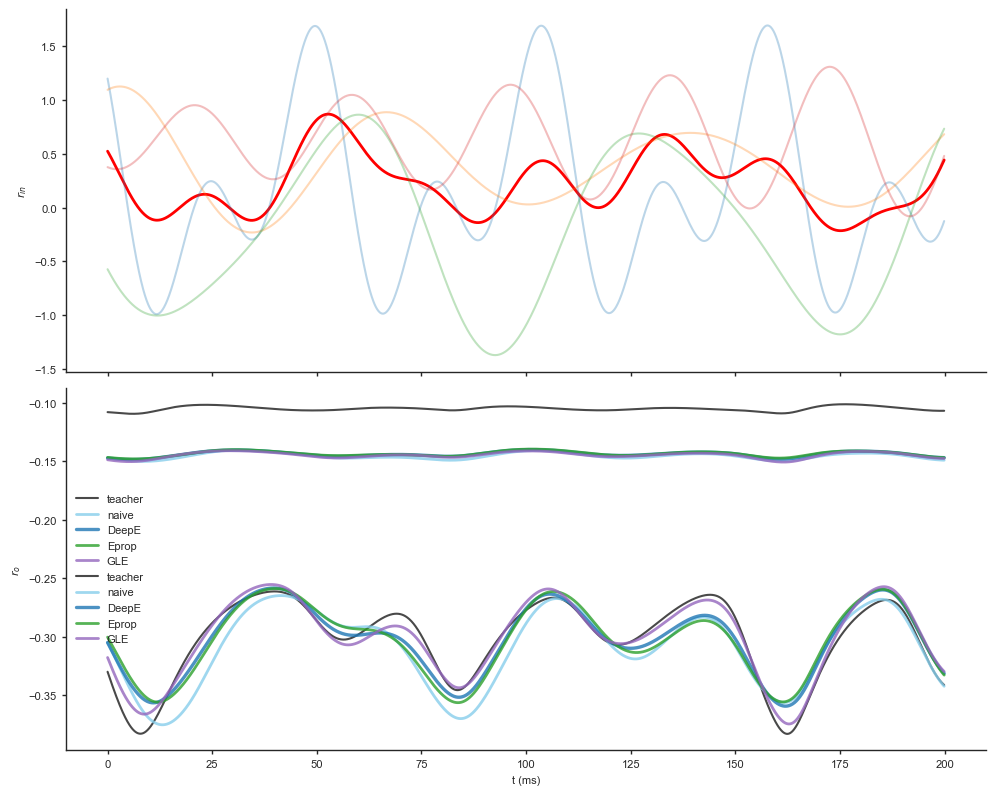

In [6]:
Rcd_eval = Recorder(['input', 'teacher', 'DeepElig', 'Eprop', 'GLE', 'naive'])
Students['naive'].align(student)
with torch.no_grad():
    for t in range(eval_phase_steps):
        t = t+init_phase_steps+learn_phase_steps
        inp = input_fuc(t)
        Rcd_eval.rec_single('input', inp)
        r_out_target, u_out_target = teacher.step(inp)
        Rcd_eval.rec_single('teacher', u_out_target)
        for k, stu in Students.items():
            r_out, u_out = stu.step(inp)
            Rcd_eval.rec_single(k, u_out)

Rcd_eval.finish()

fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
x = np.arange(0, eval_phase, dt)
axs[0].plot(x, Rcd_eval['input'].mean(axis=0), color='r', linewidth=2)
for i in range(n_in):
    axs[0].plot(x, Rcd_eval['input'][i][0:], alpha = 0.3)
for i in range(n_out):
    axs[1].plot(x, Rcd_eval['teacher'][i][0:], label="teacher", color = black, linewidth=1.5, alpha=0.8)
    axs[1].plot(x, Rcd_eval['naive'][i][0:], label="naive", color = lightblue, linewidth=2, alpha=0.8)
    axs[1].plot(x, Rcd_eval['DeepElig'][i][:], label="DeepE", color = blue, linewidth=2.4, alpha=0.8)
    axs[1].plot(x, Rcd_eval['Eprop'][i][:], label="Eprop", color = green, linewidth=2, alpha=0.8)
    axs[1].plot(x, Rcd_eval['GLE'][i][:], label="GLE", color = purple, linewidth=2, alpha=0.8)
axs[1].legend()
axs[1].set_xlabel("t (ms)")

axs[0].set_ylabel(r"$r_{in}$")
axs[1].set_ylabel(r"$r_o$")

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig('./fig/CompareAft2L.png')
plt.show()

plt.show()

In [10]:
student.layers[2].T

tensor([[ 1.0000,  0.0000, -0.1429, -0.6000, -7.0000],
        [ 0.0000,  1.0000, -0.0625, -0.2143, -0.7000]])

In [47]:
Rcd.finish()

C:\Users\Bingkun LIU\AppData\Local\Temp\ipykernel_14460\132200789.py:2: RuntimeWarning: divide by zero encountered in divide
  tau_de = np.clip(dt/(Rcd['dt_tau_de'][:, 1000:]), -30, 80)


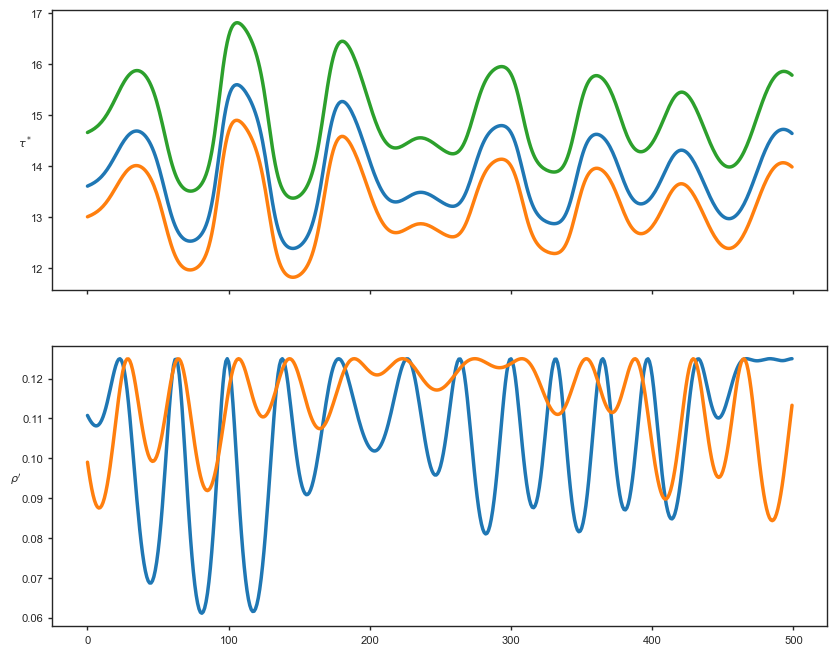

In [48]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
tau_de = np.clip(dt/(Rcd['dt_tau_de'][:, 1000:]), -30, 80)
for i in range(n_hidden1):
    axs[0].plot(tau_de[i, 8000:8500], linewidth=2.5)
for i in range(n_hidden2):
    axs[1].plot(Rcd['rhod'][i, 3000:3500], linewidth=2.5)
axs[0].set_ylabel(r"$\tau^*$", rotation=0)
axs[1].set_ylabel(r"$\rho'$", rotation=0)
plt.show()

reach steady state with error: 0.315749


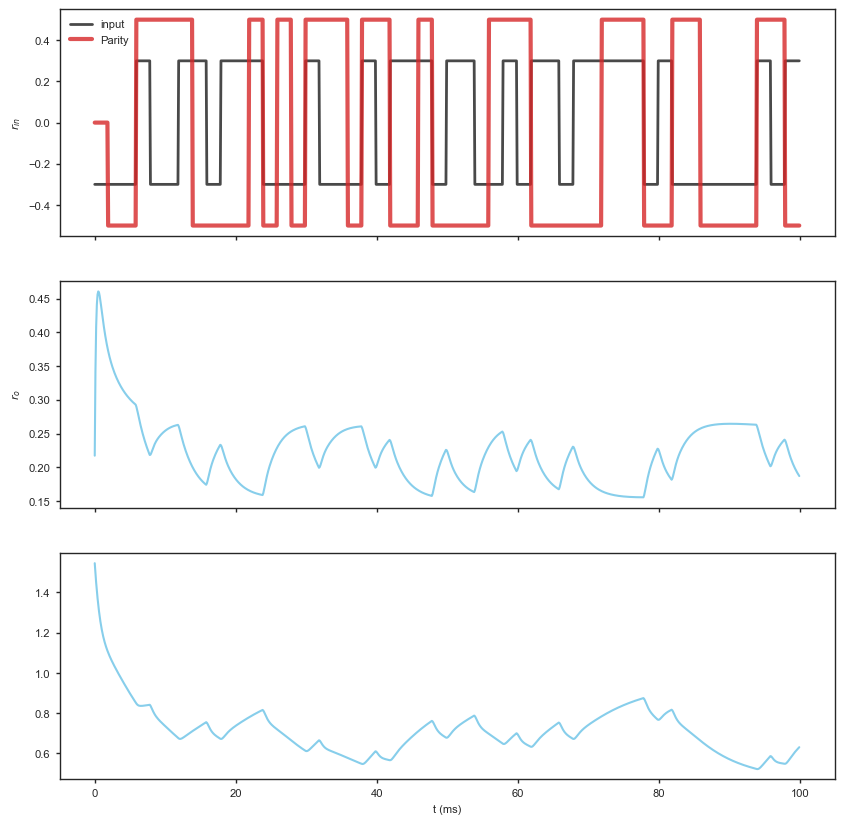

In [79]:
#### With P learning ###
dt = 0.1 #ms

init_phase = 100 #ms
init_phase_steps = int(init_phase/dt) 
learn_phase = 12000 # ms
learn_phase_steps = int(learn_phase/dt) 
eval_phase = 100 # ms
eval_phase_steps = int(eval_phase/dt)

# init both teacher and student net
N, bit_time = 3, 2

n_in, n_hidden1, n_hidden2, n_hidden3, n_out = 1, 8, 4, 4, 2
beta=0.1
activation='sigmoid'

student = DENetwork(
    layers=[
        FwdDENeurons(n_in=n_in, n_neurons=n_hidden1, tau_d = dt*np.logspace(0, 2, n_hidden1, dtype=np.float32), lr_w=1e1,
                     activation=activation, dt=dt),
        FwdDENeurons(n_in=n_hidden1, n_neurons=n_hidden2, tau_d = [2*dt, 0.8, 1.7, 3.5], lr_w=2e0,
                     activation=activation, dt=dt),
        LastNeurons(n_in=n_hidden2, n_neurons=n_hidden3, tau_d = [3*dt, 0.4, 3.7, 7.1], lr_w=0.8,
                     activation=activation, dt=dt),
        OutNeurons(n_in=n_hidden3, n_neurons=n_out, tau_d = dt, 
                   lr_w=0.2, activation='linear', dt=dt, beta=beta)
    ],)
student_naive = copy.deepcopy(student)

student2 = SequentialNetwork(net=student, layers=FwdEPNeurons)

student3 = SequentialNetwork(net=student, layers=FwdGLENeurons)

Students={'DeepElig':student, 'Eprop':student2, 'GLE':student3, 'naive':student_naive}

input_fuc = StepParity(N=N, bit_time=bit_time, dt=dt)

#recorders
Rcd = Recorder(['input', 'teacher', 'student', 'mismatch'])

with torch.no_grad():
    
    for t in range(init_phase_steps):
        input, label = input_fuc()
        r_out, u_out = student.step(input)
        Rcd.rec([input, label, u_out, student.mismatch(0)])
        
    error = label - torch.sigmoid(u_out)
    print("reach steady state with error: %f"%(error**2).mean().item())

Rcd.finish()

fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
x = np.arange(0, init_phase, dt)
axs[0].plot(x, Rcd['input'].mean(axis=0)*0.6, color=black, label='input', linewidth=2, alpha=0.8)
axs[0].plot(x, 0.5*(Rcd['teacher'][1]-Rcd['teacher'][0]), label="Parity", color = red, alpha=0.8, linewidth=3)
for i in range(n_out):
    axs[i+1].plot(x, Rcd['student'][i], label="student %d"%i, color = lightblue)


axs[-1].set_xlabel("t (ms)")
axs[0].set_ylabel(r"$r_{in}$")
axs[0].legend()
axs[1].set_ylabel(r"$r_o$")

plt.show()

In [80]:
Cum_errors = np.array(4*[(error**2).mean().item()])
error_record, mismatch_record = [], []
cum_eps = 0
Students['Eprop'].align(student)
Students['GLE'].align(student)
Rcd = Recorder(['input', 'mismatch', 'rhod'])

with torch.no_grad():
    for t in range(learn_phase_steps):
        t += init_phase_steps
        input, label = input_fuc()
        
        for i, stu in enumerate(['DeepElig', 'Eprop', 'GLE']):
            r_out, u_out = Students[stu].step(input)
            error = (label - torch.sigmoid(u_out))
            Students[stu].learnP(error)
            Students[stu].learnW()
            Cum_errors[i] = 0.999*Cum_errors[i] + 0.001*(error**2).mean().item()

        # Rcd.rec([input, student.mismatch(0), student.mismatch(-1), student.epsilon(1), 
        #          student.layers[0].rho.d, student3.mismatch(0)])
        cum_eps = 0.99*cum_eps + 0.01*(Students['DeepElig'].mismatch(0).abs()).mean().item()

        if (t*dt)%100==0:
            mismatch_record.append(cum_eps)
            error_record.append(list(Cum_errors))
            
            # for i, stu in enumerate(['DeepElig', 'Eprop', 'GLE']):
            #     Students[stu].layers[-1].beta *= 0.95
            
            print(" mismatch: %5e, error: %5e, t: %d ms"%(mismatch_record[-1], Cum_errors[0], t*dt))

Rcd.finish()
error_record = np.array(error_record).T

 mismatch: 0.000000e+00, error: 3.157496e-01, t: 100 ms
 mismatch: 0.000000e+00, error: 2.777105e-01, t: 200 ms
 mismatch: 0.000000e+00, error: 2.568120e-01, t: 300 ms
 mismatch: 0.000000e+00, error: 2.561322e-01, t: 400 ms
 mismatch: 0.000000e+00, error: 2.533742e-01, t: 500 ms
 mismatch: 0.000000e+00, error: 2.501291e-01, t: 600 ms
 mismatch: 0.000000e+00, error: 2.527005e-01, t: 700 ms
 mismatch: 0.000000e+00, error: 2.434115e-01, t: 800 ms
 mismatch: 0.000000e+00, error: 2.501893e-01, t: 900 ms
 mismatch: 0.000000e+00, error: 2.531132e-01, t: 1000 ms
 mismatch: 0.000000e+00, error: 2.519582e-01, t: 1100 ms
 mismatch: 0.000000e+00, error: 2.403008e-01, t: 1200 ms
 mismatch: 0.000000e+00, error: 2.492268e-01, t: 1300 ms
 mismatch: 0.000000e+00, error: 2.492297e-01, t: 1400 ms
 mismatch: 0.000000e+00, error: 2.473740e-01, t: 1500 ms
 mismatch: 0.000000e+00, error: 2.507880e-01, t: 1600 ms
 mismatch: 0.000000e+00, error: 2.518807e-01, t: 1700 ms
 mismatch: 0.000000e+00, error: 2.498332

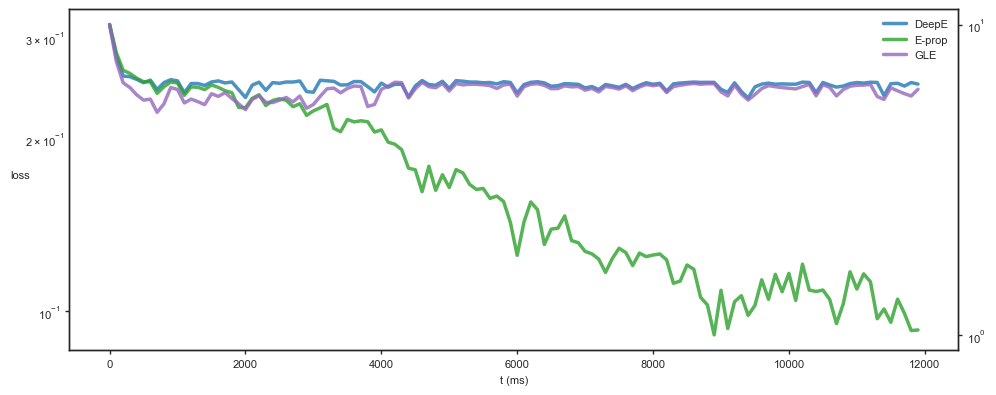

In [81]:
Error_record = np.array(error_record)#.T
fig = plt.figure(figsize=(10, 4))
time = np.arange(Error_record.shape[1])*100
ax = fig.add_subplot(111)
ax2 = ax.twinx()
ax.set_yscale('log')
ax.set_ylabel('loss', rotation=0)
ax2.set_yscale('log')
#ax2.set_ylabel(r"$\mathbf{u}^{ɑ}$", rotation=0)
l1,  = ax.plot(time, Error_record[0], label="DeepE", color=blue, linewidth=2.5, alpha=0.8)
l11, = ax.plot(time, Error_record[1], label="E-prop", color=green, linewidth=2.5, alpha=0.8)
l12, = ax.plot(time, Error_record[2], label="GLE", color=purple, linewidth=2.5, alpha=0.8)
lines = [l1, l11, l12]
labels = [line.get_label() for line in lines]
ax.legend(lines, labels, loc='upper right', frameon=False)
ax.set_xlabel('t (ms)')

plt.tight_layout()
#plt.savefig('./fig/losscurvecompare2L.png')
plt.show()

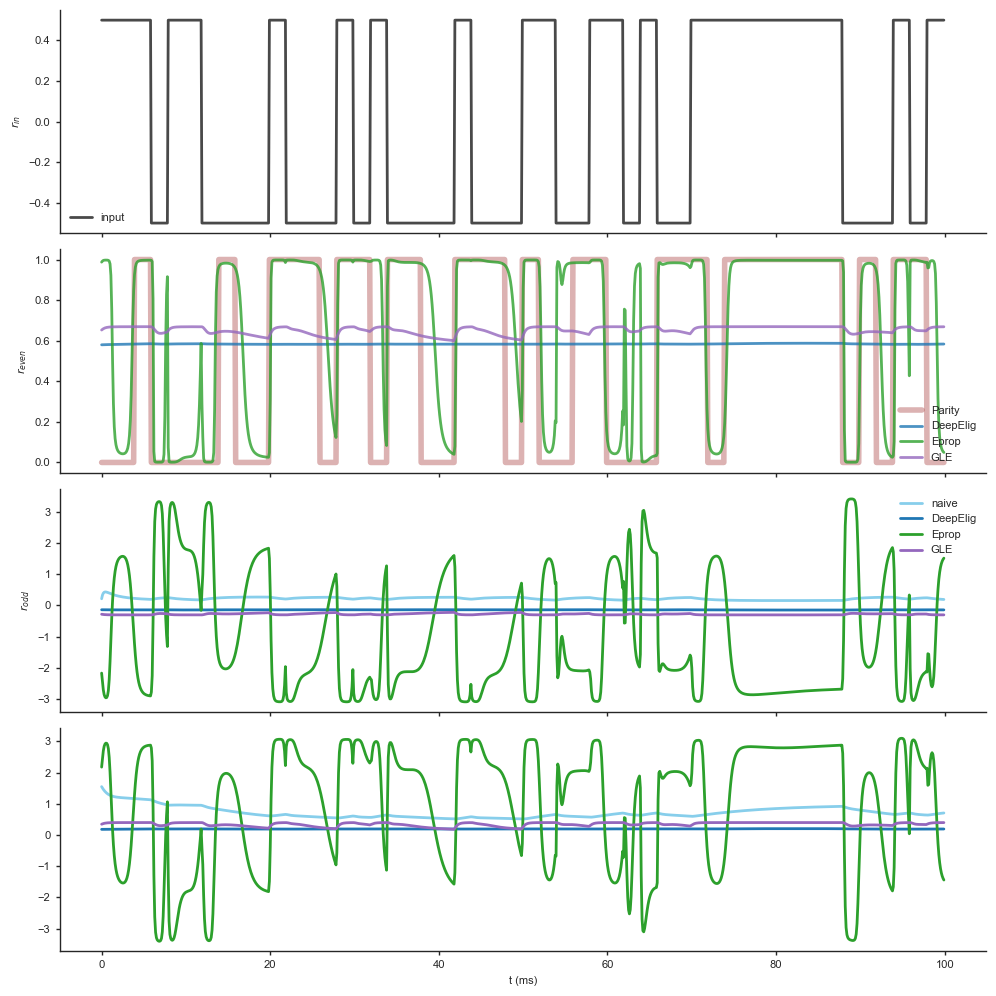

In [82]:
Rcd_eval = Recorder(['input', 'teacher', 'DeepElig', 'Eprop', 'GLE', 'naive'])

#Students['naive'].align(student)
with torch.no_grad():
    for t in range(eval_phase_steps):
        t = t+init_phase_steps+learn_phase_steps
        input, label = input_fuc()
        Rcd_eval.rec_single('input', input)
        Rcd_eval.rec_single('teacher', label)
        for k, stu in Students.items():
            r_out, u_out = stu.step(input)
            Rcd_eval.rec_single(k, u_out)

Rcd_eval.finish()



fig, axs = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
x = np.arange(0, eval_phase, dt)
axs[0].plot(x, Rcd_eval['input'].mean(axis=0), color=black, label='input', linewidth=2, alpha=0.8)

axs[1].plot(x, 0.5*(Rcd_eval['teacher'][1]-Rcd_eval['teacher'][0])+0.5, label="Parity", color=darkred, alpha=0.3, linewidth=4)
for stu, clr in zip(['DeepElig', 'Eprop', 'GLE'], [blue, green, purple, pink, lightblue]):
    prediction = np.exp(Rcd_eval[stu])
    prediction = prediction[1]/(prediction.sum(axis=0))
    axs[1].plot(x, prediction, label=stu, alpha=0.8, linewidth=2, color=clr)
    
for i in range(n_out):
    axs[i+2].plot(x, Rcd_eval['naive'][i][:], label="naive", color = lightblue, linewidth=2)
    axs[i+2].plot(x, Rcd_eval['DeepElig'][i][:], label="DeepElig", color = blue, linewidth=2)
    axs[i+2].plot(x, Rcd_eval['Eprop'][i][:], label="Eprop", color = green, linewidth=2)
    axs[i+2].plot(x, Rcd_eval['GLE'][i][:], label="GLE", color = purple, linewidth=2)
    
axs[0].legend()
axs[1].legend()
axs[2].legend()
axs[-1].set_xlabel("t (ms)")

axs[0].set_ylabel(r"$r_{in}$")
axs[1].set_ylabel(r"$r_{even}$")
axs[2].set_ylabel(r"$r_{odd}$")

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig('./fig/CompareAftRec.png')
plt.show()

## N-Sum

reach steady state with error: 0.228399


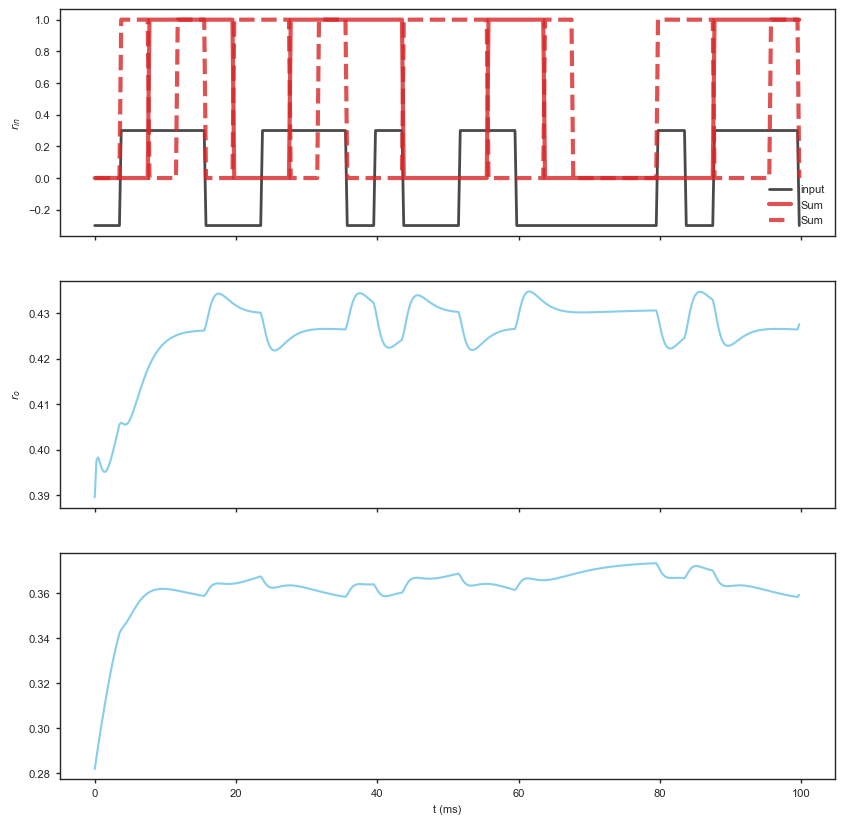

In [102]:
#### With P learning ###
dt = 0.25 #ms

init_phase = 100 #ms
init_phase_steps = int(init_phase/dt) 
learn_phase = 80000 # ms
learn_phase_steps = int(learn_phase/dt) 
eval_phase = 100 # ms
eval_phase_steps = int(eval_phase/dt)

# init both teacher and student net
N, bit_time = 3, 4

n_in, n_hidden1, n_hidden2, n_hidden3, n_out = 1, 8, 6, 6, 2
beta=torch.tensor([0.1, 0.5])
activation='sigmoid'

student = DENetwork(
    layers=[
        FwdDENeurons(n_in=n_in, n_neurons=n_hidden1, tau = dt*np.logspace(0, 1.4, n_hidden1, dtype=np.float32), lr_w=1e1,
                     activation=activation, dt=dt, bias=True, scale=1.6),
        FwdDENeurons(n_in=n_hidden1, n_neurons=n_hidden2, tau = dt*np.logspace(0, 1.1, n_hidden2, dtype=np.float32), lr_w=2.5,
                     activation=activation, dt=dt, bias=True, scale=0.4),
        LastFwdDENeurons(n_in=n_hidden2, n_neurons=n_hidden3, tau = [3*dt, 0.4, 3.7, 4.1, 1., 2.], lr_w=0.5,
                     activation='sigmoid', dt=dt, bias=True, scale=1.6),
        FwdInsNeurons(n_in=n_hidden3, n_neurons=n_out, tau = dt, 
                   lr_w=0.1, activation='sigmoid', dt=dt, beta=beta, bias=True, scale=1.)
    ],)


student2 = FwdNetwork(net=student, layers=FwdEPNeurons)

student3 = FwdNetwork(net=student, layers=FwdGLENeurons)
student_naive = copy.deepcopy(student2)

Students={'DeepElig':student, 'Eprop':student2, 'GLE':student3, 'naive':student_naive}

input_fuc = StepSumBi(N=N, bit_time=bit_time, dt=dt)

#recorders
Rcd = Recorder(['input', 'teacher', 'student'])

with torch.no_grad():
    
    for t in range(init_phase_steps):
        input, label = input_fuc()
        r_out, u_out = student.step(input)
        Rcd.rec([input, label, r_out])
        
    error = label - r_out
    print("reach steady state with error: %f"%(error**2).mean().item())

Rcd.finish()

fig, axs = plt.subplots(n_out+1, 1, figsize=(10, 10), sharex=True)
x = np.arange(0, init_phase, dt)
axs[0].plot(x, Rcd['input'].mean(axis=0)*0.6, color=black, label='input', linewidth=2, alpha=0.8)
axs[0].plot(x, Rcd['teacher'][0], label="Sum", color = red, alpha=0.8, linewidth=3)
axs[0].plot(x, Rcd['teacher'][1], label="Sum", color = red, alpha=0.8, linewidth=3, linestyle='--')
for i in range(n_out):
    axs[i+1].plot(x, Rcd['student'][i], label="student %d"%i, color = lightblue)


axs[-1].set_xlabel("t (ms)")
axs[0].set_ylabel(r"$r_{in}$")
axs[0].legend()
axs[1].set_ylabel(r"$r_o$")

plt.show()

In [103]:
Cum_errors = np.array(3*[(error**2).mean().item()])
error_record, mismatch_record = [], []
cum_eps = 0
Students['Eprop'].align(student)
Students['GLE'].align(student)
Rcd = Recorder(['input','rhod'])
decay = torch.tensor([0.997, 0.998])

with torch.no_grad():
    for t in range(learn_phase_steps):
        t += init_phase_steps
        input, label = input_fuc()
        
        for i, stu in enumerate(['DeepElig', 'Eprop', 'GLE']):
            r_out, u_out = Students[stu].step(input)
            error = label - r_out
            Students[stu].prop(error)
            Students[stu].learnW()
            Cum_errors[i] = 0.999*Cum_errors[i] + 0.001*(error**2).mean().item()

        # Rcd.rec([input, student.mismatch(0), student.mismatch(-1), student.epsilon(1), 
        #          student.layers[0].rho.d, student3.mismatch(0)])

        if (t*dt)%200==0:
            error_record.append(list(Cum_errors))
            beta *= decay
            for i, stu in enumerate(['DeepElig', 'Eprop', 'GLE']):
                Students[stu].layers[-1].beta = beta
            
            print(" error: %5e, t: %d ms"%(Cum_errors[0], t*dt))

Rcd.finish()

 error: 2.356018e-01, t: 200 ms
 error: 2.442779e-01, t: 400 ms
 error: 2.457584e-01, t: 600 ms
 error: 2.405576e-01, t: 800 ms
 error: 2.417848e-01, t: 1000 ms
 error: 2.395659e-01, t: 1200 ms
 error: 2.354443e-01, t: 1400 ms
 error: 2.385836e-01, t: 1600 ms
 error: 2.295229e-01, t: 1800 ms
 error: 2.232516e-01, t: 2000 ms
 error: 2.218267e-01, t: 2200 ms
 error: 2.239818e-01, t: 2400 ms
 error: 2.079543e-01, t: 2600 ms
 error: 2.183921e-01, t: 2800 ms
 error: 2.221527e-01, t: 3000 ms
 error: 2.290026e-01, t: 3200 ms
 error: 2.243587e-01, t: 3400 ms
 error: 2.257307e-01, t: 3600 ms
 error: 2.291945e-01, t: 3800 ms
 error: 2.296884e-01, t: 4000 ms
 error: 2.315127e-01, t: 4200 ms
 error: 2.212582e-01, t: 4400 ms
 error: 2.134517e-01, t: 4600 ms
 error: 2.122869e-01, t: 4800 ms
 error: 2.101934e-01, t: 5000 ms
 error: 2.139394e-01, t: 5200 ms
 error: 2.102572e-01, t: 5400 ms
 error: 2.110410e-01, t: 5600 ms
 error: 2.062546e-01, t: 5800 ms
 error: 1.982897e-01, t: 6000 ms
 error: 2.0470

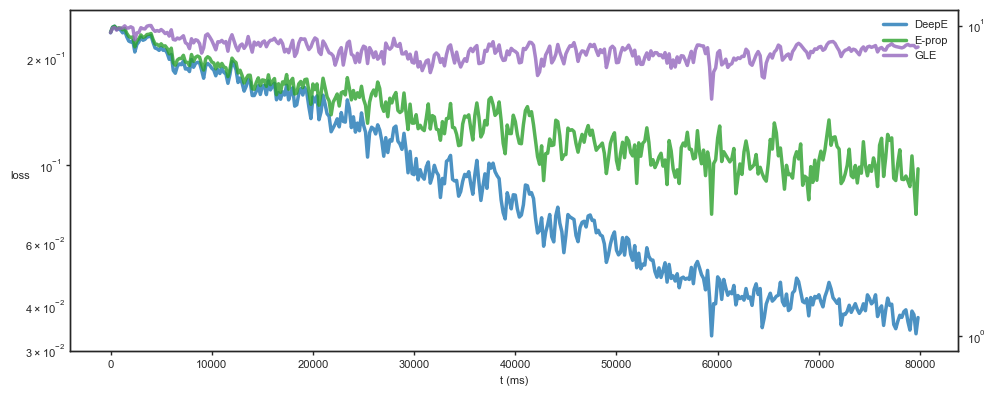

In [105]:
Error_record = np.array(error_record).T
fig = plt.figure(figsize=(10, 4))
time = np.arange(Error_record.shape[1])*200
ax = fig.add_subplot(111)
ax2 = ax.twinx()
ax.set_yscale('log')
ax.set_ylabel('loss', rotation=0)
ax2.set_yscale('log')
#ax2.set_ylabel(r"$\mathbf{u}^{ɑ}$", rotation=0)
l1,  = ax.plot(time, Error_record[0], label="DeepE", color=blue, linewidth=2.5, alpha=0.8)
l11, = ax.plot(time, Error_record[1], label="E-prop", color=green, linewidth=2.5, alpha=0.8)
l12, = ax.plot(time, Error_record[2], label="GLE", color=purple, linewidth=2.5, alpha=0.8)
lines = [l1, l11, l12]
labels = [line.get_label() for line in lines]
ax.legend(lines, labels, loc='upper right', frameon=False)
ax.set_xlabel('t (ms)')

plt.tight_layout()
#plt.savefig('./fig/losscurvecompare2L.png')
plt.show()

In [90]:
student.layers[-1].beta

tensor([0.0301, 0.2245])

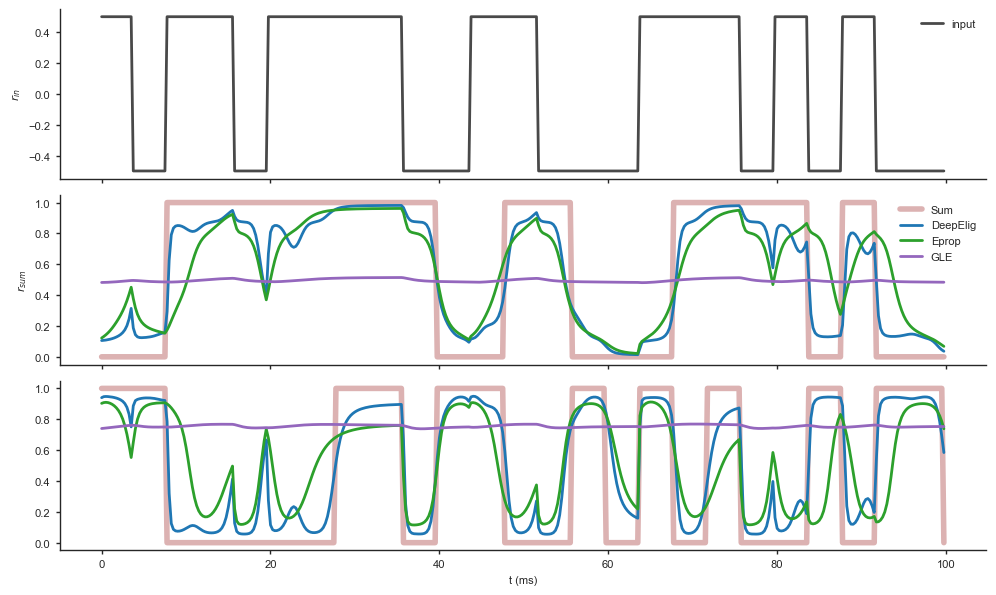

In [107]:
Rcd_eval = Recorder(['input', 'teacher', 'DeepElig', 'Eprop', 'GLE', 'naive'])

#Students['naive'].align(student)
with torch.no_grad():
    for t in range(eval_phase_steps):
        t = t+init_phase_steps+learn_phase_steps
        input, label = input_fuc()
        Rcd_eval.rec_single('input', input)
        Rcd_eval.rec_single('teacher', label)
        for k, stu in Students.items():
            r_out, u_out = stu.step(input)
            Rcd_eval.rec_single(k, r_out)

Rcd_eval.finish()



fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
x = np.arange(0, eval_phase, dt)
axs[0].plot(x, Rcd_eval['input'].mean(axis=0), color=black, label='input', linewidth=2, alpha=0.8)


    
for i in range(n_out):
    axs[i+1].plot(x, Rcd_eval['teacher'][i], label="Sum", color=darkred, alpha=0.3, linewidth=4)
    #axs[i+1].plot(x, Rcd_eval['naive'][i][:], label="naive", color = lightblue, linewidth=2)
    axs[i+1].plot(x, Rcd_eval['DeepElig'][i][:], label="DeepElig", color = blue, linewidth=2)
    axs[i+1].plot(x, Rcd_eval['Eprop'][i][:], label="Eprop", color = green, linewidth=2)
    axs[i+1].plot(x, Rcd_eval['GLE'][i][:], label="GLE", color = purple, linewidth=2)
    
axs[0].legend()
axs[1].legend()
axs[-1].set_xlabel("t (ms)")

axs[0].set_ylabel(r"$r_{in}$")
axs[1].set_ylabel(r"$r_{sum}$")

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig('./fig/CompareAftRec.png')
plt.show()

# MNIST-1D

Templates for the MNIST-1D dataset:


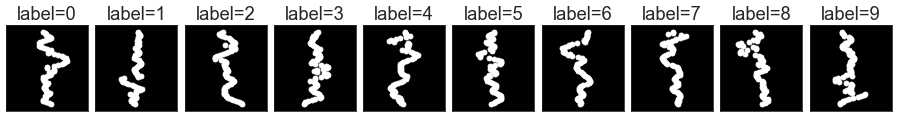

In [3]:
from mnist1d.data import make_dataset, get_dataset_args, get_templates
from mnist1d.utils import from_pickle, to_pickle, ObjectView, set_seed, plot_signals

arg_dict = ObjectView({
    'num_samples': 5000,
    'train_split': 0.8,
    'template_len': 12,
    'padding': [36,60],
    'scale_coeff': .4, 
    'max_translation': 48,
    'corr_noise_scale': 0.25,
    'iid_noise_scale': 2e-2,
    'shear_scale': 0.75,
    'shuffle_seq': False,
    'final_seq_length': 72,
    'seed': 42,
    'url': 'https://github.com/greydanus/mnist1d/raw/master/mnist1d_data.pkl'
})
data = make_dataset(arg_dict)

templates = get_templates()
print("Templates for the MNIST-1D dataset:")
x = templates['x']
t = templates['t']
y = templates['y']
fig = plot_signals(x, t, labels=y, args=arg_dict, ratio=1.33, dark_mode=True, do_transform=True)

In [79]:
print(data.keys())
x, y, t = torch.tensor(data['x'],dtype=torch.float32).unsqueeze(-1), torch.tensor(data['y']), torch.tensor(data['t'])
x.shape, y.shape, t.shape

dict_keys(['x', 'x_test', 'y', 'y_test', 't', 'templates'])


(torch.Size([4000, 72, 1]), torch.Size([4000]), torch.Size([72]))

In [80]:
#### With P learning ###
dt = 0.25 #ms
n_steps = arg_dict.final_seq_length

# init both teacher and student net
n_in, n_hidden1, n_hidden2, n_hidden3, n_hidden_ins, n_out = 1, 20, 24, 24, 40, 10
beta=0.3
activation='sigmoid'
Tau2 = torch.tensor([1.2, 2., 3.]*8)
Tau3 = torch.tensor([1.5, 2.4, 3.2]*8)

student = DENetwork(
    layers=[
        FwdDENeurons(n_in=n_in, n_neurons=n_hidden1, tau = dt+np.logspace(0, 1., n_hidden1, dtype=np.float32),
                     lr_w=2e1, activation=activation, dt=dt, scale=1.6),
        FwdDENeurons(n_in=n_hidden1, n_neurons=n_hidden2, tau = Tau2,
                     lr_w=5., activation=activation, dt=dt, scale=0.4),
        LastFwdDENeurons(n_in=n_hidden2, n_neurons=n_hidden3, tau = Tau3,
                         lr_w=1., activation=activation, dt=dt, scale=1.6),
        FwdInsNeurons(n_in=n_hidden3, n_neurons=n_hidden_ins, tau = dt, lr_w=0.1,
                      activation=activation, dt=dt, beta=beta, scale=1.),
        FwdInsNeurons(n_in=n_hidden_ins, n_neurons=n_out, tau = dt, lr_w=0.01, 
                      activation='linear', dt=dt, beta=beta, scale=1.)
    ],)

In [81]:
error_record, mismatch_record = [], []
decay = 1-2e-2
Cum_errors = 4
num_epochs = 30
with torch.no_grad():
    for epoch in range(num_epochs):
        permu = np.random.permutation(4000)
        for i, idx in enumerate(permu):
            total_error = 0.
            one_hot_label = torch.zeros(10)   
            one_hot_label[y[idx]] = 1.
            sample = x[idx]
            for t in range(n_steps):
                r_out, u_out = student.step(sample[t])
                if t>70:
                    p = torch.softmax(r_out, dim=0)
                    error = one_hot_label - p
                    student.prop(error)
                    student.learnW()
                    total_error += -(one_hot_label * torch.log(p)).sum().item()
                else:
                    student.prop(0)
            student.reset()
            Cum_errors = 0.98*Cum_errors + 0.02*total_error
        
            if i%500==0:
                error_record.append(Cum_errors)
                beta *= decay
                student.layers[-1].beta = beta       
                print(" error: %5e, iteration: %d samples"%(Cum_errors, i))

 error: 4.010648e+00, iteration: 0 samples
 error: 2.050845e+00, iteration: 500 samples
 error: 2.030220e+00, iteration: 1000 samples
 error: 2.003660e+00, iteration: 1500 samples
 error: 1.865571e+00, iteration: 2000 samples
 error: 1.834659e+00, iteration: 2500 samples
 error: 1.882859e+00, iteration: 3000 samples
 error: 1.844164e+00, iteration: 3500 samples
 error: 1.664227e+00, iteration: 0 samples
 error: 1.836019e+00, iteration: 500 samples
 error: 1.843303e+00, iteration: 1000 samples
 error: 1.971985e+00, iteration: 1500 samples
 error: 1.753740e+00, iteration: 2000 samples
 error: 1.764326e+00, iteration: 2500 samples
 error: 1.778142e+00, iteration: 3000 samples
 error: 1.689035e+00, iteration: 3500 samples
 error: 1.788640e+00, iteration: 0 samples
 error: 1.746802e+00, iteration: 500 samples
 error: 1.687120e+00, iteration: 1000 samples
 error: 1.760686e+00, iteration: 1500 samples
 error: 1.739166e+00, iteration: 2000 samples
 error: 1.696125e+00, iteration: 2500 samples


In [69]:
student.layers[-1].beta

0.17745759368913536

In [76]:
#TEST
x, y = torch.tensor(data['x_test'],dtype=torch.float32).unsqueeze(-1), torch.tensor(data['y_test'])
prediction = []
Cum_errors = 0.
with torch.no_grad():
    for idx in range(1000):
        total_error = 0.
        sample = x[idx]
        for t in range(n_steps):
            r_out, u_out = student.step(sample[t])
        prediction.append(torch.argmax(r_out).item())
        student.reset()
prediction= torch.tensor(prediction)
print('Accuracy: ', ((prediction==y)*1.).mean())

Accuracy:  tensor(0.3700)
